<a href="https://colab.research.google.com/github/kpriyanka93/Hotel-Booking-Analysis/blob/main/yes_bank_m6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Regression - Yes Bank Stock Closing Price Prediction**

Problem Statement

Yes Bank, one of India’s prominent private sector banks, has experienced significant fluctuations in its stock prices over the years — especially following the 2018 financial fraud case involving its founder, Rana Kapoor. These events have raised questions about the predictability and stability of the bank’s stock performance.

The goal of this project is to analyze historical monthly stock price data of Yes Bank and develop predictive models that can accurately forecast the closing price of the stock for upcoming months.

In [3]:
# Mount google drive here in google colab to access drive files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#  Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


In [5]:
# Loading the dataset
df = pd.read_csv("/content/drive/MyDrive/m6_project/YesBank_StockPrices.csv")

In [6]:
# Top five rows
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [7]:
# Dimension of dataset
df.shape

(185, 5)

In [8]:
# Columns of dataset
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

Metadata:
1. Date : month and year
2. Open: The price of the stock at the beginning of the trading period (e.g., the first trade of the day).
3. High: The highest price at which the stock was traded during that period.
4. Low: The lowest price at which the stock was traded during that period.
5. Close: The final or last traded price of the stock at the end of the trading period.


#  Data Preprocessing

In [9]:
# Convert Date column to datetime
from datetime import datetime
df['Date'] = pd.to_datetime(df['Date'].apply(lambda x: datetime.strptime(x,'%b-%y')))
df.head()


,Date,Open,High,Low,Close
0,2005-07-01,13.00,14.00,11.25,12.46
1,2005-08-01,12.58,14.88,12.55,13.42
2,2005-09-01,13.48,14.87,12.27,13.30
3,2005-10-01,13.20,14.47,12.40,12.99
4,2005-11-01,13.35,13.88,12.88,13.41


In [10]:
# Check for missing values
print(df.isnull().sum())

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64


In [11]:
# Set date as index for time series analysis
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close
Date,,,,
2005-07-01,13.00,14.00,11.25,12.46
2005-08-01,12.58,14.88,12.55,13.42
2005-09-01,13.48,14.87,12.27,13.30
2005-10-01,13.20,14.47,12.40,12.99
2005-11-01,13.35,13.88,12.88,13.41


# Exploratory Data Analysis (EDA)

In [12]:
# Summary statistics
print(df.describe())

             Open        High         Low       Close
count  185.000000  185.000000  185.000000  185.000000
mean   105.541405  116.104324   94.947838  105.204703
std     98.879850  106.333497   91.219415   98.583153
min     10.000000   11.240000    5.550000    9.980000
25%     33.800000   36.140000   28.510000   33.450000
50%     62.980000   72.550000   58.000000   62.540000
75%    153.000000  169.190000  138.350000  153.300000
max    369.950000  404.000000  345.500000  367.900000


In [13]:
# Identify Numerical Columns
numerical_col = df.describe().columns
numerical_col

Index(['Open', 'High', 'Low', 'Close'], dtype='object')

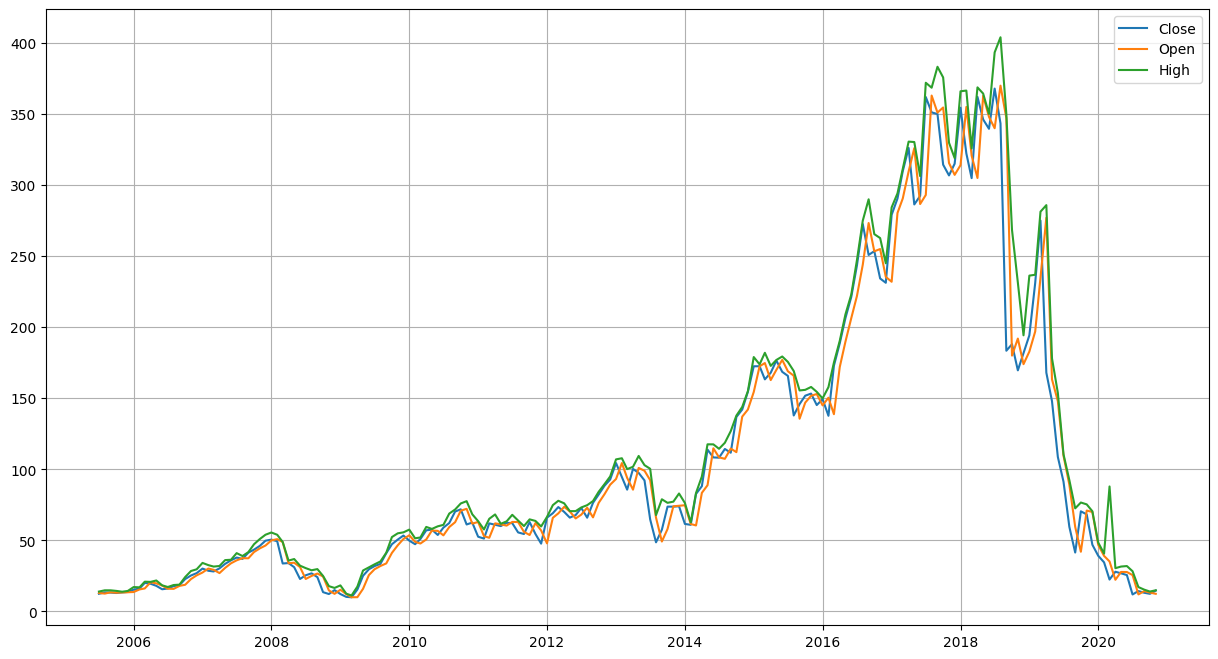

In [14]:
# Line Plot
plt.figure(figsize=(15,8))
plt.plot(df['Close'])
plt.plot(df['Open'])
plt.plot(df['High'])
plt.legend(['Close','Open','High'])
plt.grid()

In [15]:
# Extract year and month
df['Year'] = df.index.year
df['Month'] = df.index.month


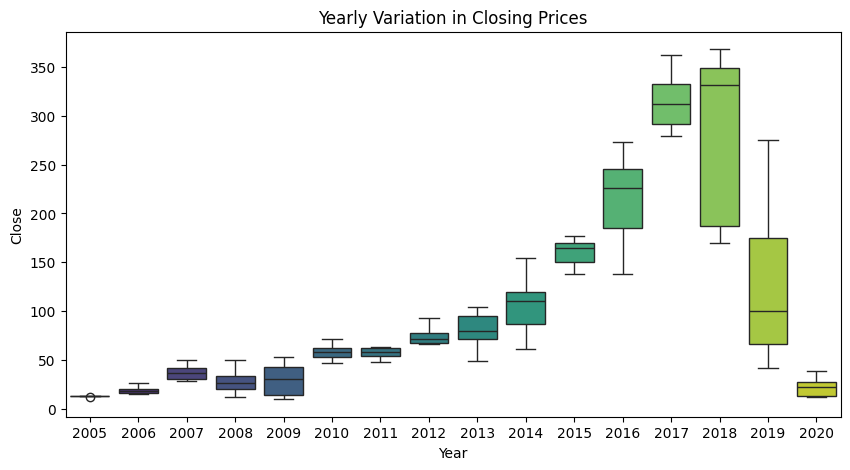

In [16]:
# Yearly trends
plt.figure(figsize=(10,5))
sns.boxplot(x='Year', y='Close', data=df, palette='viridis')
plt.title('Yearly Variation in Closing Prices')
plt.show()

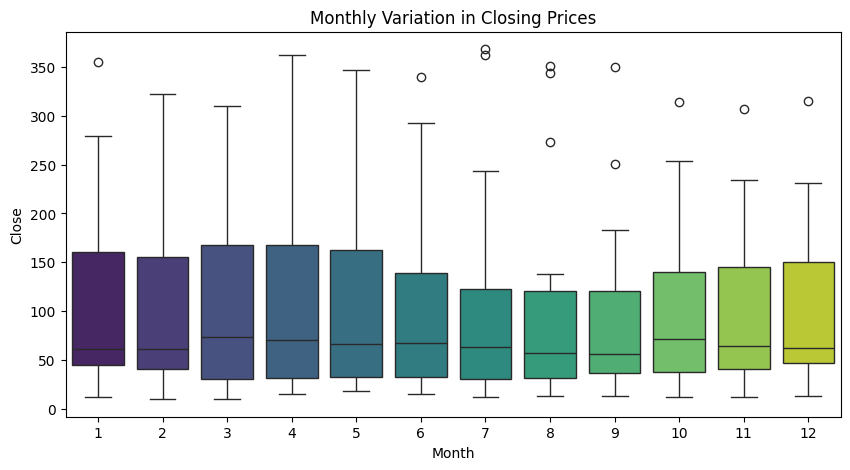

In [17]:
# Monthly trends
plt.figure(figsize=(10,5))
sns.boxplot(x='Month', y='Close', data=df, palette='viridis')
plt.title('Monthly Variation in Closing Prices')
plt.show()

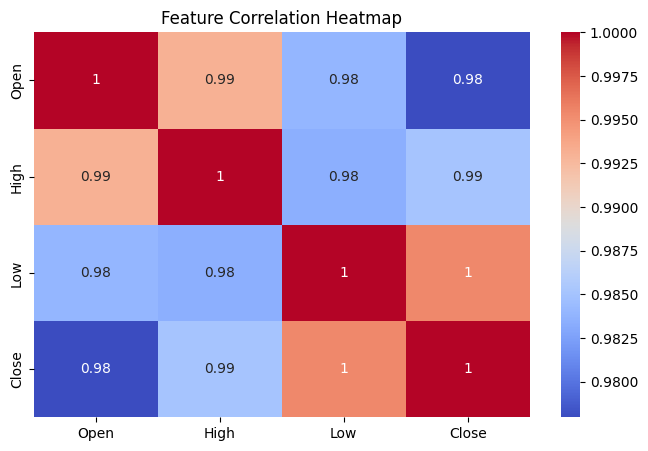

In [18]:
# Feature Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[['Open','High','Low','Close']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# The strong correlation between opening, high, low and closing prices—indicating that internal price dynamics drive most monthly movements.

Feature Engineering

In [19]:
# Create lag features (previous month's prices)
df['Prev_Close'] = df['Close'].shift(1)
df['Prev_Open'] = df['Open'].shift(1)
df['Prev_High'] = df['High'].shift(1)
df['Prev_Low'] = df['Low'].shift(1)


In [20]:
# Drop first row (NaN due to shift)
df = df.dropna()

# Target variable
y = df['Close']

# Features
X = df[['Open', 'High', 'Low', 'Prev_Close', 'Prev_Open', 'Prev_High', 'Prev_Low']]

Train-Test Split

In [21]:
# Using 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (147, 7)
Test shape: (37, 7)


Model 1: Linear Regression

In [22]:
# Creating a LinearRegression object
lr = LinearRegression()
# Train the mdoel using the provided training data
lr.fit(X_train, y_train)


LinearRegression()

In [23]:
# Prediction
y_pred_lr = lr.predict(X_test)

In [24]:
# Evaluation
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression:")
print(f"R² = {r2_lr:.3f}, MAE = {mae_lr:.3f}, RMSE = {rmse_lr:.3f}")


Linear Regression:
R² = 0.985, MAE = 9.982, RMSE = 15.599


Model 2: Random Forest Regressor

In [25]:
# Creating a RegressionForest object
rf = RandomForestRegressor(n_estimators=200, random_state=42)

# Train the mdoel using the provided training data
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [26]:
# Prediction of random forest model
y_pred_rf = rf.predict(X_test)


In [27]:
# Evaluation of model
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Regressor:")
print(f"R² = {r2_rf:.3f}, MAE = {mae_rf:.3f}, RMSE = {rmse_rf:.3f}")

Random Forest Regressor:
R² = 0.959, MAE = 16.186, RMSE = 25.855


Comparing the prediction of linear regresssion model and random forest model

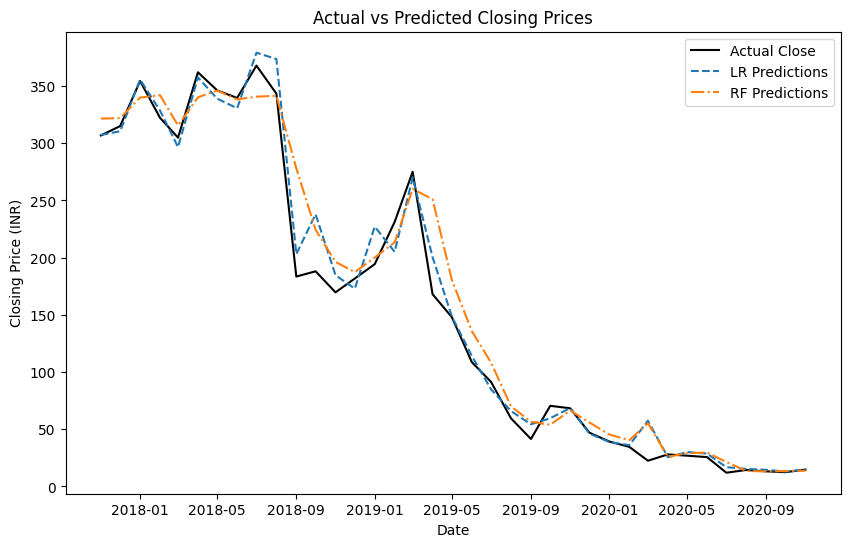

In [28]:
plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test.values, label='Actual Close', color='black')
plt.plot(y_test.index, y_pred_lr, label='LR Predictions', linestyle='--')
plt.plot(y_test.index, y_pred_rf, label='RF Predictions', linestyle='-.')
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.legend()
plt.show()


Model Evaluation Summary

In [29]:
eval_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [r2_lr, r2_rf],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf]
})
eval_df


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.985180,9.981627,15.599070
1,Random Forest,0.959286,16.186169,25.855055


# Linear Regression performed better than Random Forest(lower MAE & RMSE) for given dataset

Forecasting for Next Month

In [30]:
latest = df.iloc[-1]  # last known month

new_input = pd.DataFrame({
    'Open': [latest['Open']],
    'High': [latest['High']],
    'Low': [latest['Low']],
    'Prev_Close': [latest['Close']],
    'Prev_Open': [latest['Open']],
    'Prev_High': [latest['High']],
    'Prev_Low': [latest['Low']]
})

future_close = lr.predict(new_input)
print(f"📈 Predicted Next Month's Closing Price: ₹{future_close[0]:.2f}")


📈 Predicted Next Month's Closing Price: ₹17.63


Conclusion

->The project demonstrates that, under steady conditions, historical monthly price data combined with engineered features can produce reasonably accurate closing-price forecasts for Yes Bank.
->However, the model’s sensitivity to abrupt external events (like fraud or regulatory upheavals) remains a limitation—underline that forecasts should support but not replace qualitative judgment.
->By extending the model with richer data and real-time signals, Yes Bank (and its stakeholders) can further enhance predictive reliability and strategic insight.